In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
plt.style.use('dark_background')

In [2]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Data (Study Hours and Pass/Fail)
X = np.array([[1], [2.5], [3], [4.5], [5], [6]])   # Feature
y = np.array([ 0,    0,    0,    1,    1,   1])    # Target

# Create and train the model
model = LogisticRegression()
model.fit(X, y)

# Predict probabilities for new students
hours = np.array([[3.4],])
probs = model.predict_proba(hours)

# Display the probabilities of passing (class 1)
for h, p in zip(hours.flatten(), probs[:, 1]):
    print(f"Study Hours: {h}, Probability of Passing: {p:.2f}")


Study Hours: 3.4, Probability of Passing: 0.41


In [3]:
# Now lets look at the coefficient b0 and b1
b0 = model.intercept_[0]   # Intercept term
b1 = model.coef_[0][0]     # Coefficient for Study Hours

print(f"b0 (intercept): {b0}")
print(f"b1 (coefficient): {b1}")

b0 (intercept): -4.35104689377748
b1 (coefficient): 1.1694435780672545


In [4]:
# Now lets calculate the probability using the formula:
import math

# z = b0 + b1*x
z = -4.35 + 1.17*3.4
print("z:", z)

prob = 1 / (1 + math.exp(-z)) # the sigmoid function
print("Probability:", prob)

z: -0.3719999999999999
Probability: 0.40805783960041075


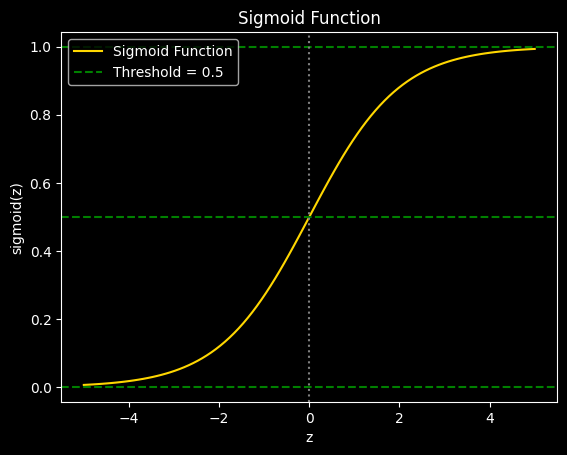

In [5]:

# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate x values
z = np.linspace(-5, 5, 100)

# Compute sigmoid values
y = sigmoid(z)

# Scatter plot of sigmoid curve
# plt.scatter(z, y, color='gold', label='Sigmoid Function', s=20, marker=".")
plt.plot(z, y, color='gold', label='Sigmoid Function', )

# Add reference lines
plt.axhline(0.5, color='green', linestyle='--', label='Threshold = 0.5')
plt.axhline(1, color='green', linestyle='--',)
plt.axhline(0, color='green', linestyle='--',)

plt.axvline(0, color='gray', linestyle=':')

# Labels and title
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.legend()
# plt.grid(True)
plt.show()

In [6]:
# logistic regression for many features
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Features: X1, X2, X3
X = np.array([
    [2.5, 1.3, 0.5],
    [1.0, 3.5, 2.2],
    [3.2, 0.9, 1.4],
    [4.1, 2.2, 0.1],
    [0.9, 4.5, 3.1],
    [3.9, 1.2, 0.4]
])

# Target values (binary)
y = np.array([1, 0, 1, 1, 0, 1])

# Train logistic regression
model = LogisticRegression()
model.fit(X, y)

# Predict probability for a new sample
x_new = np.array([[3.0, 1.5, 0.7]])

prob = model.predict_proba(x_new)
print("Probability y=1:", prob[0][1])

Probability y=1: 0.9006659215352736


In [7]:
prob

array([[0.09933408, 0.90066592]])

In [3]:
#  Manual z-score calculation
weights = model.coef_[0]       # array of w1, w2, w3
intercept = model.intercept_[0] # w0

# Coefficients (weights) and intercept
print("Weights (w1, w2, w3) =", weights)
print("Intercept (w0) =", intercept)


z = intercept + np.dot(x_new, weights)
print("Z-score =", z)

#  Manual sigmoid calculation
sigmoid = 1 / (1 + np.exp(-z))
print("Sigmoid (manual prob) =", sigmoid)


Weights (w1, w2, w3) = [ 0.65657282 -0.70048368 -0.51619173]
Intercept (w0) = 1.6469869761114737
Z-score = [2.2046457]
Sigmoid (manual prob) = [0.90066592]


# Multiclass

In [ ]:
# implement soft-max function
import numpy as np

# Raw model scores (logits)
z = np.array([2.0, 1.0, 0.1])

# Step 1: Exponentiate the scores
exp_z = np.exp(z)

# Step 2: Normalize by the sum
softmax = exp_z / np.sum(exp_z)

print("Softmax Probabilities:", softmax)
print("Sum of probabilities:", np.sum(softmax))

In [ ]:
from sklearn.utils.extmath import softmax
import numpy as np

z = np.array([[2.0, 1.0, 0.1]])  # Must be 2D (n_samples, n_classes)

probs = softmax(z)
print("Softmax Probabilities:", probs)

In [3]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

X = np.array([120, 135, 150, 160, 175, 190, 55, 65, 70]).reshape(-1, 1)
y_fruits = np.array([
    "Apple", "Apple", "Apple",
    "Banana", "Banana", "Banana",
    "Grape", "Grape", "Grape"
])

# Encode fruit labels as numbers
le = LabelEncoder()
y = le.fit_transform(y_fruits)   # converts to 0,1,2

print("Label Mapping:")
for fruit, label in zip(le.classes_, range(len(le.classes_))):
    print(fruit, "->", label, end="; ")

# Train multinomial logistic regression
model = LogisticRegression(multi_class="multinomial", solver="lbfgs")
model.fit(X, y)

# Predict for a new fruit
weight_new = np.array([[150]])     # test weight
probs = model.predict_proba(weight_new)
probs = np.round(probs, 6)

print("\n\nPredicted probabilities for weight 150g:")
print(f"Apple : {probs[0][0]};\n Banana: {probs[0][1]};\n Grape : {probs[0][2]}")
print("\nPredicted Class:", le.inverse_transform(model.predict(weight_new))[0])

Label Mapping:
Apple -> 0; Banana -> 1; Grape -> 2; 

Predicted probabilities for weight 150g:
Apple : 0.929444;
 Banana: 0.070545;
 Grape : 1e-05

Predicted Class: Apple


In [2]:
# Behind the scene look:
# Display learned parameters
print("\nWeights (w_k for each class):")
print(model.coef_)   # shape: (3 classes × 1 feature)

print("\nIntercepts (b_k for each class):")
print(model.intercept_)

# Manual z-score calculation
weights = model.coef_[:, 0]     # w_k for each class
biases = model.intercept_       # b_k for each class

z_scores = weights * weight_new + biases
print("\nZ-scores (one for each class):")
print(z_scores)


Weights (w_k for each class):
[[-0.13092316]
 [ 0.47075254]
 [-0.33982934]]

Intercepts (b_k for each class):
[ 24.42271852 -68.83699135  44.41427283]

Z-scores (one for each class):
[[ 4.78424381  1.7758899  -6.56012846]]


In [5]:
# multiclass 
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from scipy.special import softmax

# 1. Read the CSV file
df = pd.read_csv("data_iris.csv")
print(df.head(10))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
8           4.4          2.9           1.4          0.2  setosa
9           4.9          3.1           1.5          0.1  setosa


In [6]:
# 2. Split features (X) and target (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = df['species'].values
print(X[:5])
print(y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
['setosa' 'setosa' 'setosa' 'setosa' 'setosa']


In [10]:
# 3. Encode target labels (e.g., setosa → 0, versicolor → 1, virginica → 2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Label Mapping:")
for flower, label in zip(encoder.classes_, range(len(encoder.classes_))):
    print(flower, "->", label, end="; ")


Label Mapping:
setosa -> 0; versicolor -> 1; virginica -> 2; 

In [14]:
# 4. Train a multinomial logistic regression model (uses Softmax internally)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model.fit(X, y_encoded)

# 5. Take one sample (sepal_length,sepal_width,petal_length,petal_width) = (6.1,2.9,4.7,1.4) 
sample = np.array([6.1,2.9,4.7,1.4]).reshape(1, -1)
predicted = model.predict(sample)
print(predicted) # versicolor

[1]


In [15]:
# Behind the scene look
# Display learned parameters
print("\nWeights (w_k for each class):")
print(model.coef_)   # shape: (3 classes × 1 feature)

print("\nIntercepts (b_k for each class):")
print(model.intercept_)

# Manual z-score calculation
weights = model.coef_[:, 0]     # w_k for each class
biases = model.intercept_       # b_k for each class

z_scores = weights * weight_new + biases
print("\nZ-scores (one for each class):")
print(z_scores)


Weights (w_k for each class):
[[-0.42452989  0.96294725 -2.51998995 -1.08064885]
 [ 0.53432825 -0.31684353 -0.20537388 -0.94170926]
 [-0.10979836 -0.64610372  2.72536383  2.02235811]]

Intercepts (b_k for each class):
[  9.8811247    2.21689156 -12.09801626]

Z-scores (one for each class):
[[-53.79835943  82.36612897 -28.56776954]]


In [ ]:
# (OPTIONAL)5.2 Take one sample (sepal_length,sepal_width,petal_length,petal_width) = (6.1,2.9,4.7,1.4) 
# and get the raw model scores (logits)
sample = np.array([6.1,2.9,4.7,1.4]).reshape(1, -1) # This should be versicolor
z = model.decision_function(sample)
print("Raw model scores (logits):", z)

# 6. Apply softmax manually to convert scores → probabilities
probs = softmax(z)
print("Softmax probabilities:", probs)
print("Predicted class index:", np.argmax(probs))
print("Predicted class label:", encoder.inverse_transform([np.argmax(probs)])[0])


Weights (w_k for each class):
[[-0.42452989  0.96294725 -2.51998995 -1.08064885]
 [ 0.53432825 -0.31684353 -0.20537388 -0.94170926]
 [-0.10979836 -0.64610372  2.72536383  2.02235811]]

Intercepts (b_k for each class):
[  9.8811247    2.21689156 -12.09801626]

Z-scores (one for each class):
[[-53.79835943  82.36612897 -28.56776954]]
